
## Price History Viewer

This notebook provides reusable helpers to:
1. Load one specific parquet and print it as a dataframe.
2. Plot price history from that parquet.

The plotting style matches the original notebook, with:
- legend format: `Seller_{n}_{rule actions}`
- `max_steps` sampled from the **tail** of the parquet.


In [7]:

import sys
from pathlib import Path
from typing import Optional, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def _locate_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "src" / "strategies.py").exists():
            return base
        if (base / "pricing_marl" / "src" / "strategies.py").exists():
            return base / "pricing_marl"
    raise RuntimeError("Cannot locate project root containing src/strategies.py")


project_root = _locate_project_root()
results_root = project_root / "data" / "results"

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.environment import compute_nash_and_monopoly_static, get_demand_and_profit_static

try:
    from src.strategies import ID_TO_NAME
except Exception:
    ID_TO_NAME = {
        0: "Undercut",
        1: "Match",
        2: "Above",
        3: "Under+Reset",
        4: "Match+Reset",
    }

sns.set_context("talk")
plt.rcParams["figure.figsize"] = (15, 6)


In [8]:

def _mu_to_str(mu: Union[str, float]) -> str:
    if isinstance(mu, str):
        return mu
    return f"{mu:g}"


def resolve_parquet_path(
    path: Optional[Union[str, Path]] = None,
    *,
    strats: Optional[int] = None,
    N: Optional[int] = None,
    k: Optional[int] = None,
    mu: Optional[Union[str, float]] = None,
    run: Optional[int] = None,
    base_dir: Optional[Union[str, Path]] = None,
) -> Path:
    if path is not None:
        return Path(path)

    required = {
        "strats": strats,
        "N": N,
        "k": k,
        "mu": mu,
        "run": run,
    }
    missing = [name for name, value in required.items() if value is None]
    if missing:
        raise ValueError(f"Missing required args when path is None: {missing}")

    root = Path(base_dir) if base_dir is not None else results_root
    return root / f"scan_{strats}strats_mu{_mu_to_str(mu)}_k{k}" / f"N_{N}" / f"run_{run}.parquet"


def _extract_params_from_path(parquet_path: Path):
    strats_val = None
    k_val = None
    mu_val = None
    N_val = None
    run_val = None

    parts = parquet_path.parts
    for part in parts:
        if part.startswith("scan_"):
            # Expected format: scan_{strats}strats_mu{mu}_k{k}
            tokens = part.split("_")
            if len(tokens) >= 4 and tokens[1].endswith("strats") and tokens[2].startswith("mu") and tokens[3].startswith("k"):
                strats_token = tokens[1].replace("strats", "")
                strats_val = int(strats_token) if strats_token.isdigit() else strats_val
                mu_val = tokens[2].replace("mu", "") or mu_val
                k_token = tokens[3].replace("k", "")
                k_val = int(k_token) if k_token.isdigit() else k_val
        elif part.startswith("N_"):
            n_token = part.split("_", 1)[1]
            N_val = int(n_token) if n_token.isdigit() else N_val
        elif part.startswith("run_") and part.endswith(".parquet"):
            run_token = part.replace("run_", "").replace(".parquet", "")
            run_val = int(run_token) if run_token.isdigit() else run_val

    return {
        "strats": strats_val,
        "N": N_val,
        "k": k_val,
        "mu": mu_val,
        "run": run_val,
    }


def _resolve_plot_meta(parquet_path: Path, strats, N, k, mu, run):
    inferred = _extract_params_from_path(parquet_path)
    return {
        "strats": strats if strats is not None else inferred["strats"],
        "N": N if N is not None else inferred["N"],
        "k": k if k is not None else inferred["k"],
        "mu": _mu_to_str(mu) if mu is not None else inferred["mu"],
        "run": run if run is not None else inferred["run"],
    }


def load_parquet_df(
    path: Optional[Union[str, Path]] = None,
    *,
    strats: Optional[int] = None,
    N: Optional[int] = None,
    k: Optional[int] = None,
    mu: Optional[Union[str, float]] = None,
    run: Optional[int] = None,
    base_dir: Optional[Union[str, Path]] = None,
):
    parquet_path = resolve_parquet_path(
        path,
        strats=strats,
        N=N,
        k=k,
        mu=mu,
        run=run,
        base_dir=base_dir,
    )
    if not parquet_path.exists():
        raise FileNotFoundError(f"Parquet file not found: {parquet_path}")

    df = pd.read_parquet(parquet_path)
    return df, parquet_path


def print_parquet(
    path: Optional[Union[str, Path]] = None,
    *,
    strats: Optional[int] = None,
    N: Optional[int] = None,
    k: Optional[int] = None,
    mu: Optional[Union[str, float]] = None,
    run: Optional[int] = None,
    base_dir: Optional[Union[str, Path]] = None,
    rows: Optional[int] = 5,
):
    df, parquet_path = load_parquet_df(
        path,
        strats=strats,
        N=N,
        k=k,
        mu=mu,
        run=run,
        base_dir=base_dir,
    )
    print(f"Loaded: {parquet_path}")
    print(f"Shape: {df.shape}")

    if rows is None:
        display(df)
    else:
        display(df.head(rows))
    return df


def _seller_idx_from_col(col_name: str) -> int:
    return int(col_name.split("_", 1)[1])


def _seller_actions_label(plot_data: pd.DataFrame, seller_idx: int) -> str:
    action_col = f"a_{seller_idx}"
    if action_col not in plot_data.columns:
        return f"Seller_{seller_idx}_NoActionCol"

    unique_action_ids = []
    seen = set()
    for action in plot_data[action_col].dropna().tolist():
        action_id = int(action)
        if action_id not in seen:
            seen.add(action_id)
            unique_action_ids.append(action_id)

    action_names = [ID_TO_NAME.get(aid, f"Unknown({aid})") for aid in unique_action_ids]
    action_text = "/".join(action_names) if action_names else "NoAction"
    return f"Seller_{seller_idx}_{action_text}"


def _build_figure_path(meta: dict, steps_count: int, save_subdir: str) -> Path:
    figures_root = project_root / "analysis" / "figures"
    output_dir = figures_root / save_subdir
    output_dir.mkdir(parents=True, exist_ok=True)

    filename = (
        f"price_history_strats{meta['strats']}_N{meta['N']}_k{meta['k']}_"
        f"mu{meta['mu']}_run{meta['run']}_last{steps_count}.png"
    )
    return output_dir / filename


def plot_price_history(
    path: Optional[Union[str, Path]] = None,
    *,
    strats: Optional[int] = None,
    N: Optional[int] = None,
    k: Optional[int] = None,
    mu: Optional[Union[str, float]] = None,
    run: Optional[int] = None,
    base_dir: Optional[Union[str, Path]] = None,
    max_steps: Optional[int] = 200,
    save_fig: bool = False,
    save_subdir: str = "viz_history_exports",
):
    df, parquet_path = load_parquet_df(
        path,
        strats=strats,
        N=N,
        k=k,
        mu=mu,
        run=run,
        base_dir=base_dir,
    )

    if max_steps is None:
        plot_data = df.copy()
    else:
        if max_steps <= 0:
            raise ValueError("max_steps must be a positive integer or None")
        plot_data = df.tail(max_steps).copy()  # Tail slice (latest observations)

    p_cols = sorted(
        [c for c in plot_data.columns if c.startswith("p_")],
        key=_seller_idx_from_col,
    )
    if not p_cols:
        raise ValueError("No price columns like 'p_0', 'p_1', ... were found")

    profit_cols = sorted(
        [
            c
            for c in plot_data.columns
            if c.startswith("pi_") or c.startswith("profit_")
        ],
        key=_seller_idx_from_col,
    )
    if not profit_cols:
        raise ValueError("No profit columns like 'pi_0'/'profit_0', 'pi_1'/'profit_1', ... were found")

    x_values = plot_data["t_global"] if "t_global" in plot_data.columns else plot_data.index

    plt.figure(figsize=(15, 5))
    price_offset_per_seller = 0.002  # Slight vertical offset to reduce overlap
    for p_col in p_cols:
        seller_idx = _seller_idx_from_col(p_col)
        label = _seller_actions_label(plot_data, seller_idx)
        y_values = plot_data[p_col] + seller_idx * price_offset_per_seller
        plt.step(
            x_values,
            y_values,
            label=label,
            marker=".",
            markersize=4,
            alpha=0.7,
        )

    meta = _resolve_plot_meta(parquet_path, strats, N, k, mu, run)

    avg_profit_all_sellers = float(plot_data[profit_cols].to_numpy().mean())
    avg_delta_all_sellers = float("nan")
    try:
        mu_val = float(meta["mu"])
        n_sellers = len(profit_cols)
        p_nash, p_mon = compute_nash_and_monopoly_static(
            num_sellers=n_sellers,
            a_val=2.0,
            mu=mu_val,
            a0=0.0,
            c_val=1.0,
        )
        pi_nash = float(get_demand_and_profit_static([p_nash] * n_sellers, 2.0, mu_val, 0.0, 1.0)[0])
        pi_mon = float(get_demand_and_profit_static([p_mon] * n_sellers, 2.0, mu_val, 0.0, 1.0)[0])
        denominator = pi_mon - pi_nash
        if abs(denominator) > 1e-12:
            avg_delta_all_sellers = (avg_profit_all_sellers - pi_nash) / denominator
    except Exception as exc:
        print(f"Warning: failed to compute avg Delta from avg profit ({exc})")
    step_text = f"last {len(plot_data)} steps" if max_steps is not None else f"all {len(plot_data)} steps"
    title = (
        f"Price History | Rules Set={meta['strats']}, N={meta['N']}, k={meta['k']}, "
        f"mu={meta['mu']}, run={meta['run']} | {step_text}"
    )
    plt.title(title)
    avg_profit_text = f"{avg_profit_all_sellers:.2f}"
    avg_delta_text = f"{avg_delta_all_sellers:.2f}" if not np.isnan(avg_delta_all_sellers) else "N/A"
    stats_text = (
        f"Avg Profit (all sellers): {avg_profit_text}\n"
        f"Avg $\\Delta$ (all sellers): {avg_delta_text}"
    )
    ax = plt.gca()
    ax.text(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox={"facecolor": "white", "edgecolor": "gray", "alpha": 0.85},
    )
    plt.xlabel("Time Step (t)")
    plt.ylabel("Price")
    plt.ylim(0.8, 2.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    saved_path = None
    if save_fig:
        saved_path = _build_figure_path(meta, len(plot_data), save_subdir)
        plt.savefig(saved_path, dpi=200, bbox_inches="tight")
        print(f"Saved figure: {saved_path}")

    plt.show()

    return plot_data, saved_path


In [9]:

# One-line dataframe print example
df_preview = print_parquet(strats=3, N=10, k=30, mu=0.04, run=0, rows=8)


Loaded: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/data/results/scan_3strats_mu0.04_k30/N_10/run_0.parquet
Shape: (9990, 39)


,run_id,t_global,episode,step_in_k,price_min,price_mean,delta,converged,is_cycle,a_0,...,pi_6,a_7,p_7,pi_7,a_8,p_8,pi_8,a_9,p_9,pi_9
0,0,0,542906,0,2.098115,2.098115,0.525457,True,False,0,...,0.050788,0,2.098115,0.050788,0,2.098115,0.050788,0,2.098115,0.050788
1,0,1,542906,1,1.966406,1.966406,1.000000,True,False,0,...,0.092641,0,1.966406,0.092641,0,1.966406,0.092641,0,1.966406,0.092641
2,0,2,542906,2,1.834697,1.834697,0.894502,True,False,0,...,0.083336,0,1.834697,0.083336,0,1.834697,0.083336,0,1.834697,0.083336
3,0,3,542906,3,1.702989,1.702989,0.746634,True,False,0,...,0.070295,0,1.702989,0.070295,0,1.702989,0.070295,0,1.702989,0.070295
4,0,4,542906,4,1.571280,1.571280,0.597343,True,False,0,...,0.057128,0,1.571280,0.057128,0,1.571280,0.057128,0,1.571280,0.057128
5,0,5,542906,5,1.439571,1.439571,0.448009,True,False,0,...,0.043957,0,1.439571,0.043957,0,1.439571,0.043957,0,1.439571,0.043957
6,0,6,542906,6,1.307863,1.307863,0.298672,True,False,0,...,0.030786,0,1.307863,0.030786,0,1.307863,0.030786,0,1.307863,0.030786
7,0,7,542906,7,1.176154,1.176154,0.149336,True,False,0,...,0.017615,0,1.176154,0.017615,0,1.176154,0.017615,0,1.176154,0.017615


Saved figure: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/analysis/figures/viz_price_history_selected/price_history_strats3_N10_k30_mu0.04_run1_last150.png


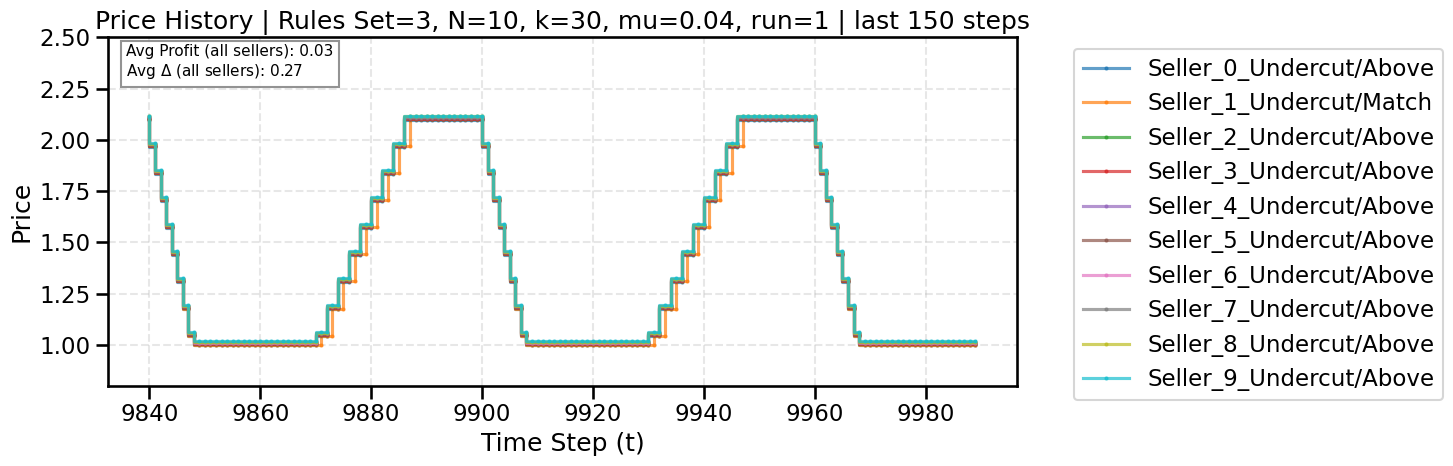

Saved figure: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/analysis/figures/viz_price_history_selected/price_history_strats3_N10_k30_mu0.1_run1_last150.png


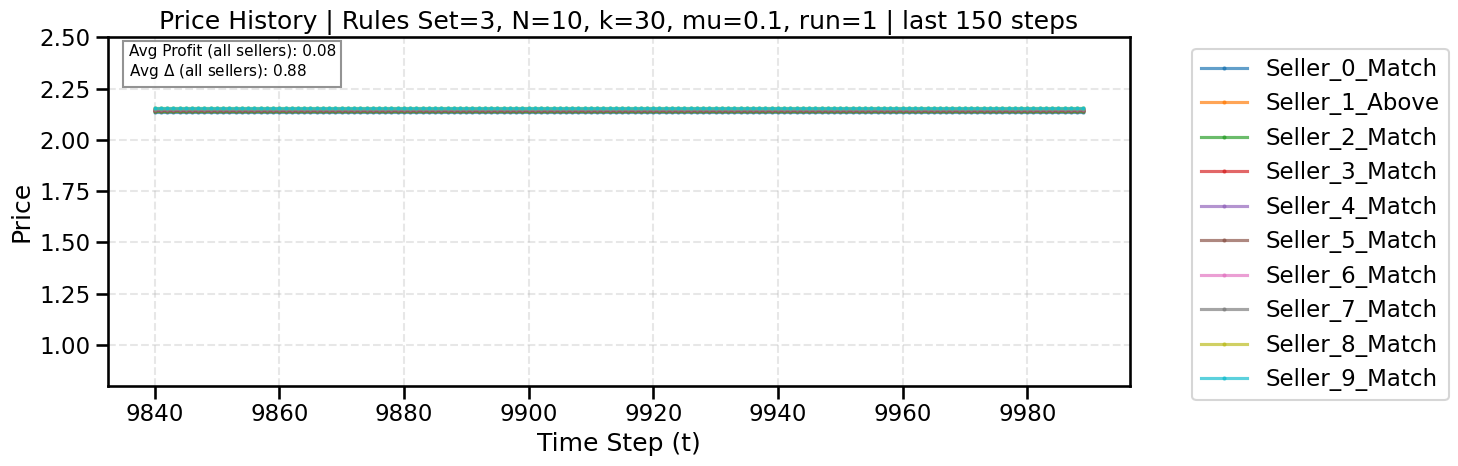

Saved figure: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/analysis/figures/viz_price_history_selected/price_history_strats3_N10_k30_mu0.25_run1_last150.png


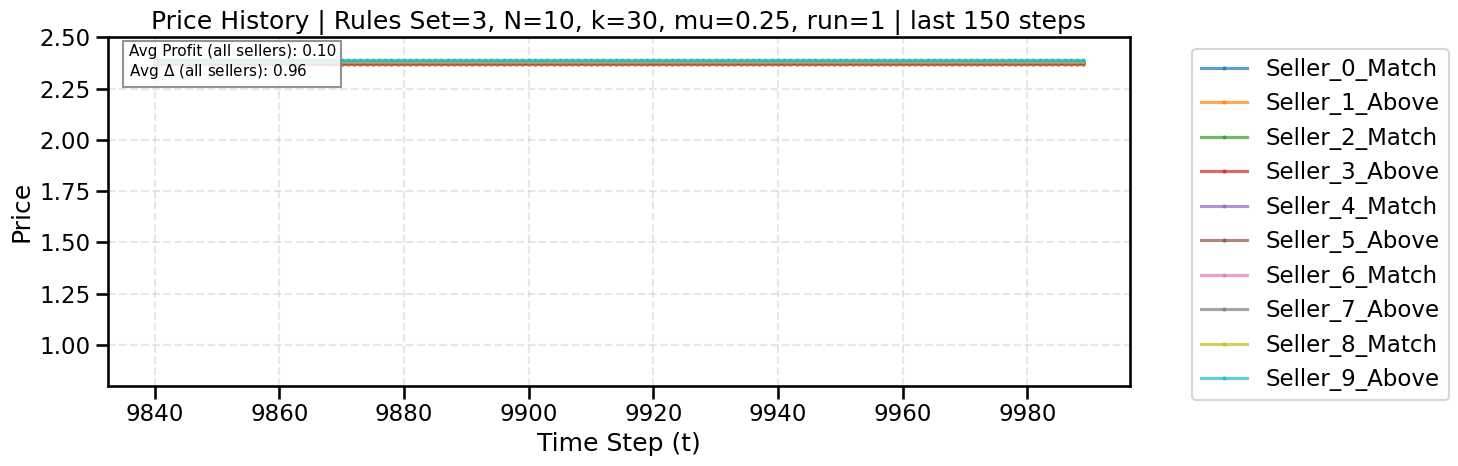

Saved figure: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/analysis/figures/viz_price_history_selected/price_history_strats4_N10_k30_mu0.04_run1_last150.png


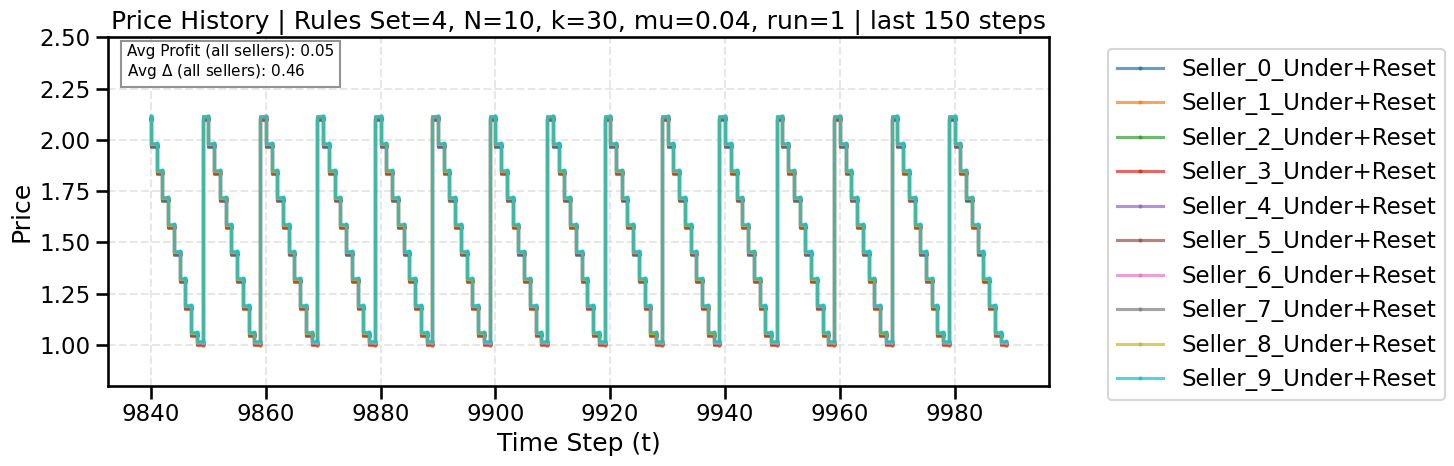

Saved figure: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/analysis/figures/viz_price_history_selected/price_history_strats4_N10_k30_mu0.1_run1_last150.png


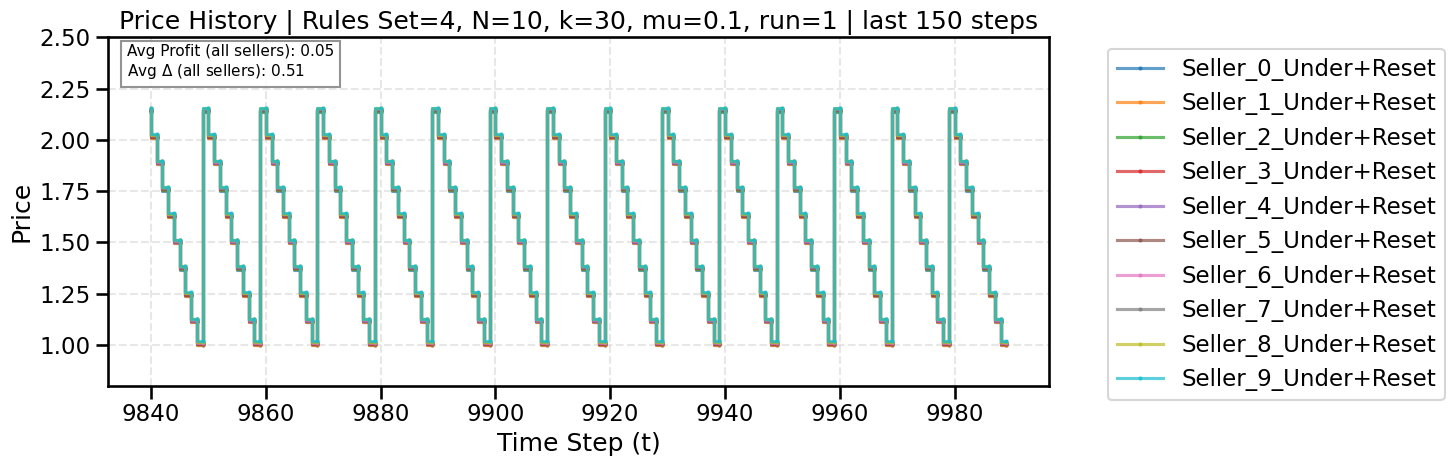

Saved figure: /Users/liushijian/Documents/GitHub/Amazon_BuyBox_Reinforcement_Learning/pricing_marl/analysis/figures/viz_price_history_selected/price_history_strats4_N10_k30_mu0.25_run1_last150.png


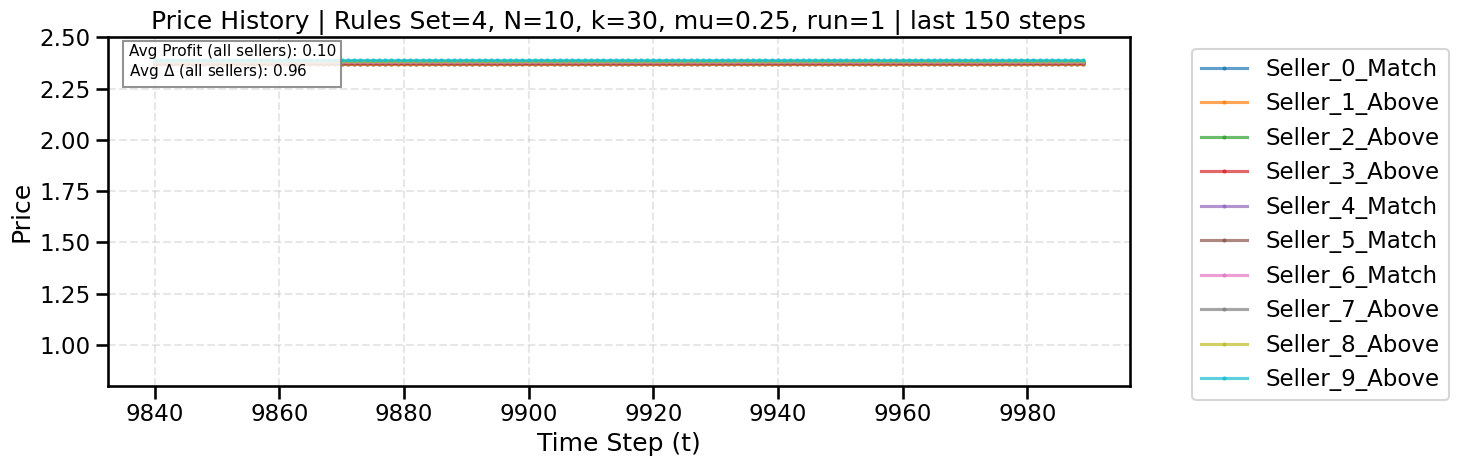

In [10]:

# Draw and save selected plots
MAX_STEPS = 150
FIGURE_SUBDIR = "viz_price_history_selected"
TARGET_RUNS = [
    {"strats": 3, "N": 10, "k": 30, "mu": 0.04, "run": 1},
    {"strats": 3, "N": 10, "k": 30, "mu": 0.1, "run": 1},
    {"strats": 3, "N": 10, "k": 30, "mu": 0.25, "run": 1},
    {"strats": 4, "N": 10, "k": 30, "mu": 0.04, "run": 1},
    {"strats": 4, "N": 10, "k": 30, "mu": 0.1, "run": 1},
    {"strats": 4, "N": 10, "k": 30, "mu": 0.25, "run": 1},
]

for cfg in TARGET_RUNS:
    plot_price_history(**cfg, max_steps=MAX_STEPS, save_fig=True, save_subdir=FIGURE_SUBDIR)


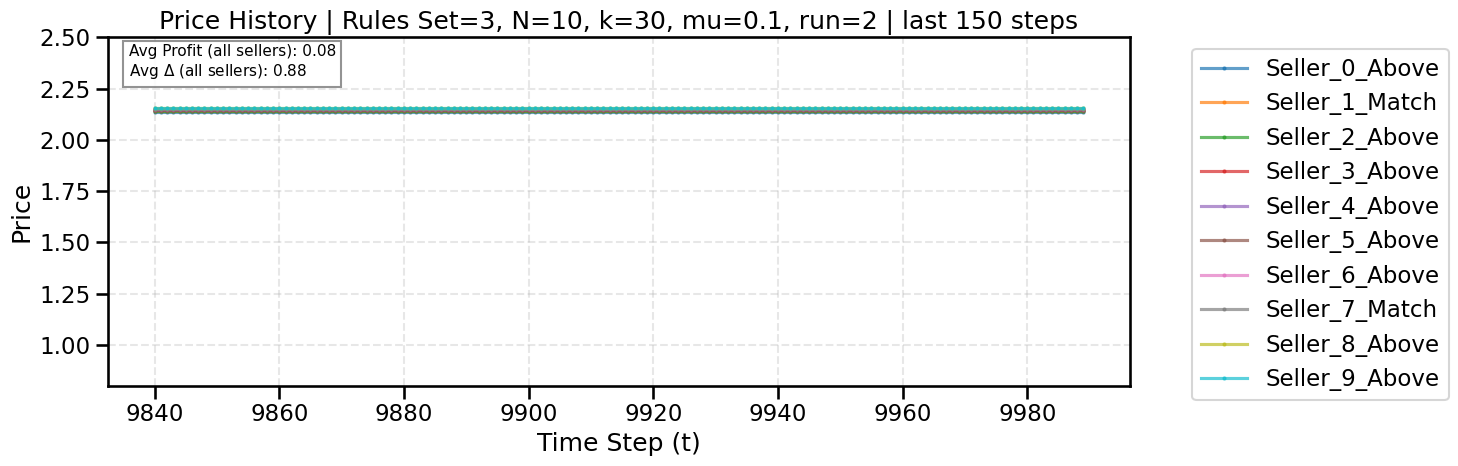

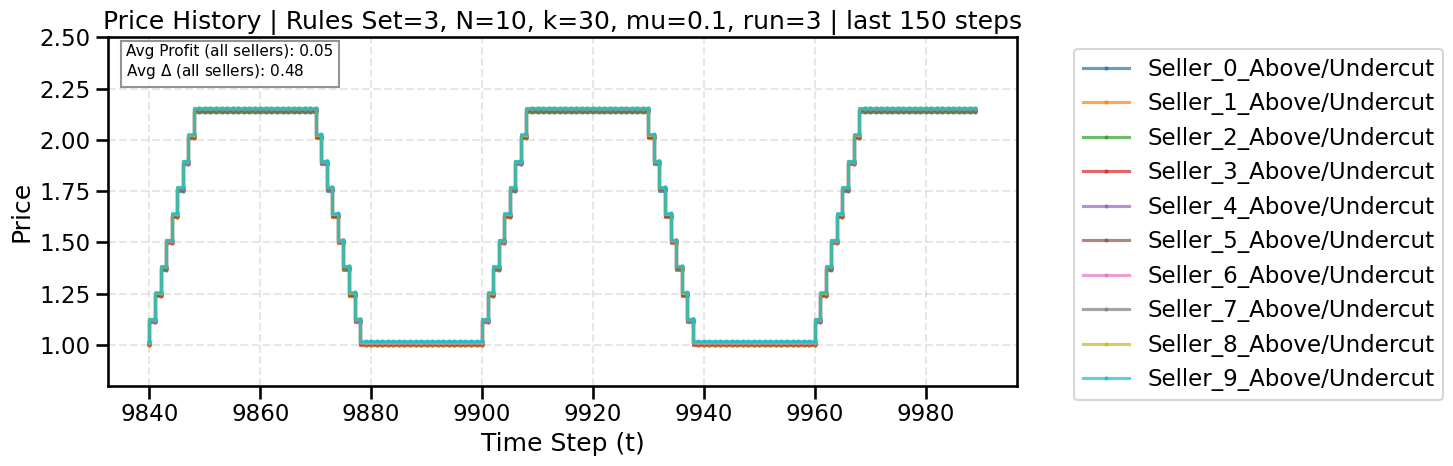

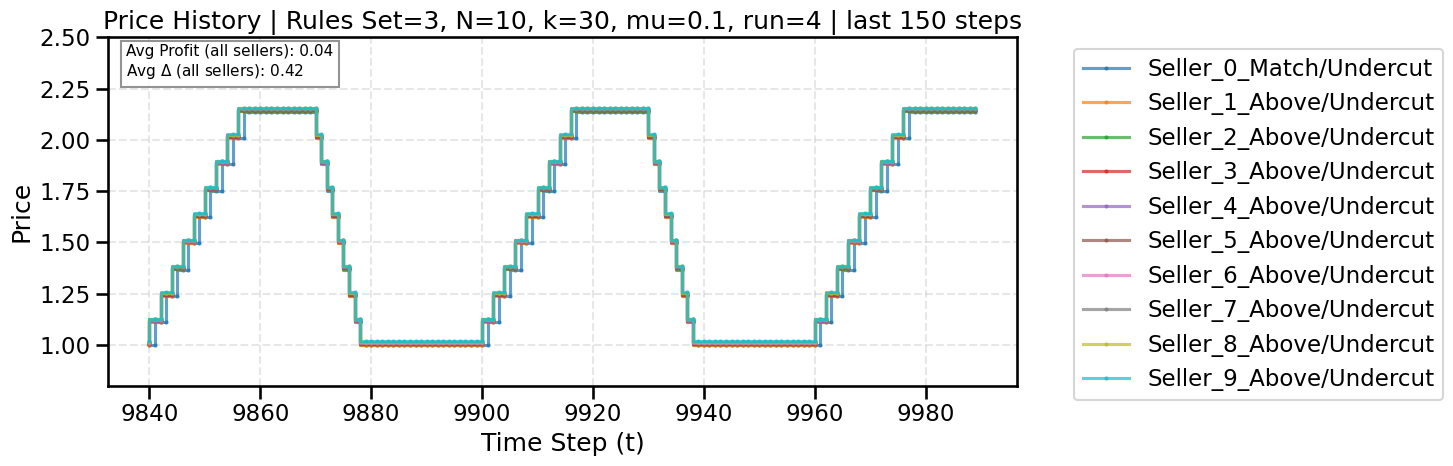

In [11]:
# Draw and don't save selected plots
MAX_STEPS = 150
FIGURE_SUBDIR = "viz_price_history_selected"
TARGET_RUNS = [
    {"strats": 3, "N": 10, "k": 30, "mu": 0.1, "run": 2},
    {"strats": 3, "N": 10, "k": 30, "mu": 0.1, "run": 3},
    {"strats": 3, "N": 10, "k": 30, "mu": 0.1, "run": 4},
]

for cfg in TARGET_RUNS:
    plot_price_history(**cfg, max_steps=MAX_STEPS, save_fig=False, save_subdir=FIGURE_SUBDIR)


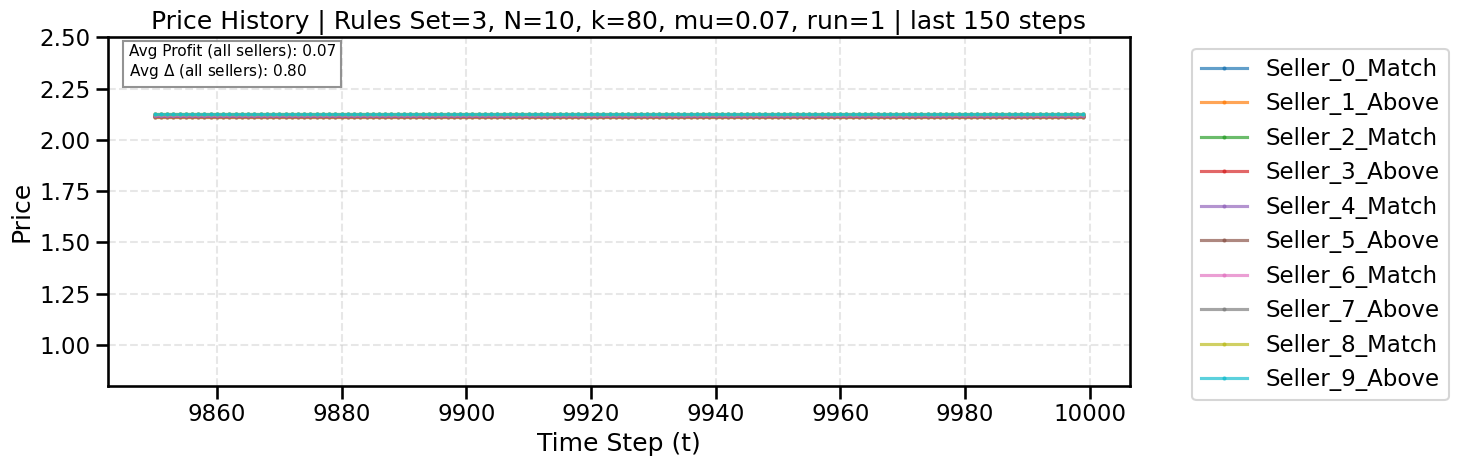

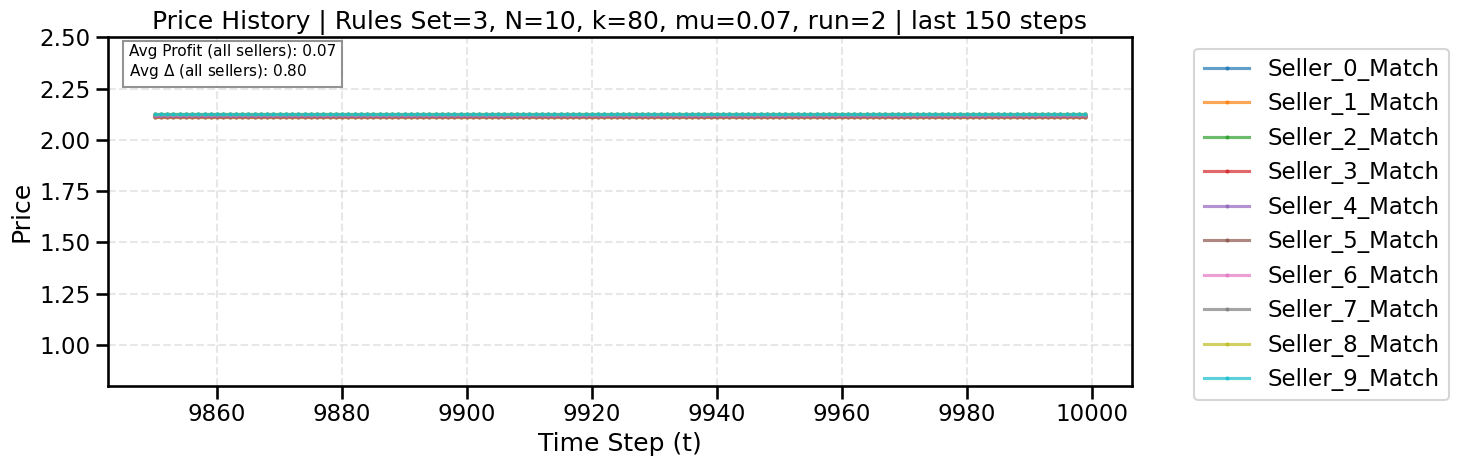

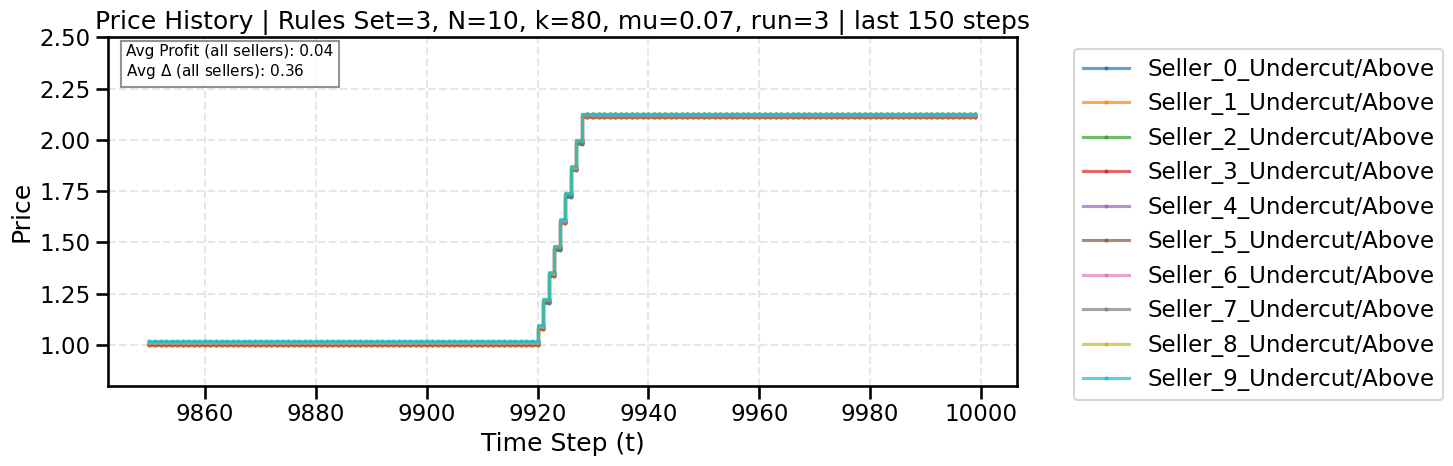

In [12]:
# Draw and don't save selected plots
MAX_STEPS = 150
FIGURE_SUBDIR = "viz_price_history_selected"
TARGET_RUNS = [
    {"strats": 3, "N": 10, "k": 80, "mu": 0.07, "run": 1},
    {"strats": 3, "N": 10, "k": 80, "mu": 0.07, "run": 2},
    {"strats": 3, "N": 10, "k": 80, "mu": 0.07, "run": 3},
]

for cfg in TARGET_RUNS:
    plot_price_history(**cfg, max_steps=MAX_STEPS, save_fig=False, save_subdir=FIGURE_SUBDIR)
